
#  IMPORTATION DES BIBLIOTHÈQUES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#  CHARGEMENT DU DATASET

In [2]:
df = pd.read_csv(
    "validations_metro_final.csv",
    sep=";"
)

print("Aperçu du dataset :")
display(df.head())

print("\nDimensions du dataset :", df.shape)

print("\nColonnes disponibles :")
print(df.columns)

Aperçu du dataset :


,nom_emplacement_trouve,CAT_JOUR,TRNC_HORR_60,heure,latitude,longitude,Pourcentage_validations,ligne,mode,exploitant,terval,idf,principale,nb_lignes,lignes_detail
0,ÉPÔNE-MÉZIÈRES,JOVS,6H-7H,6,48.963344,1.809095,12.08,TRAIN J / TRAIN N,TRAIN,SNCF,0,1,0,2,TRAIN J / TRAIN N
1,ÉPÔNE-MÉZIÈRES,SAHV,16H-17H,16,48.963344,1.809095,6.80,TRAIN J / TRAIN N,TRAIN,SNCF,0,1,0,2,TRAIN J / TRAIN N
2,ÉPÔNE-MÉZIÈRES,SAHV,18H-19H,18,48.963344,1.809095,4.44,TRAIN J / TRAIN N,TRAIN,SNCF,0,1,0,2,TRAIN J / TRAIN N
3,ÉPÔNE-MÉZIÈRES,SAHV,20H-21H,20,48.963344,1.809095,2.65,TRAIN J / TRAIN N,TRAIN,SNCF,0,1,0,2,TRAIN J / TRAIN N
4,ÉPÔNE-MÉZIÈRES,SAHV,23H-0H,23,48.963344,1.809095,0.27,TRAIN J / TRAIN N,TRAIN,SNCF,0,1,0,2,TRAIN J / TRAIN N



Dimensions du dataset : (85576, 15)

Colonnes disponibles :
Index(['nom_emplacement_trouve', 'CAT_JOUR', 'TRNC_HORR_60', 'heure',
       'latitude', 'longitude', 'Pourcentage_validations', 'ligne', 'mode',
       'exploitant', 'terval', 'idf', 'principale', 'nb_lignes',
       'lignes_detail'],
      dtype='object')


#  NETTOYAGE DES NOMS DE COLONNES

In [3]:
df.columns = df.columns.str.strip()

print("Colonnes après nettoyage :")
print(df.columns)

Colonnes après nettoyage :
Index(['nom_emplacement_trouve', 'CAT_JOUR', 'TRNC_HORR_60', 'heure',
       'latitude', 'longitude', 'Pourcentage_validations', 'ligne', 'mode',
       'exploitant', 'terval', 'idf', 'principale', 'nb_lignes',
       'lignes_detail'],
      dtype='object')


#  SÉLECTION DES COLONNES UTILES

In [4]:
colonnes_utiles = [
    "nom_emplacement_trouve",
    "CAT_JOUR",
    "TRNC_HORR_60",
    "heure",
    "latitude",
    "longitude",
    "ligne",
    "mode",
    "exploitant",
    "principale",
    "nb_lignes",
    "Pourcentage_validations"
]

df = df[colonnes_utiles].copy()

print("Dataset après sélection des colonnes :")
display(df.head())

Dataset après sélection des colonnes :


,nom_emplacement_trouve,CAT_JOUR,TRNC_HORR_60,heure,latitude,longitude,ligne,mode,exploitant,principale,nb_lignes,Pourcentage_validations
0,ÉPÔNE-MÉZIÈRES,JOVS,6H-7H,6,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,12.08
1,ÉPÔNE-MÉZIÈRES,SAHV,16H-17H,16,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,6.80
2,ÉPÔNE-MÉZIÈRES,SAHV,18H-19H,18,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,4.44
3,ÉPÔNE-MÉZIÈRES,SAHV,20H-21H,20,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,2.65
4,ÉPÔNE-MÉZIÈRES,SAHV,23H-0H,23,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,0.27


In [5]:
seuil = df["Pourcentage_validations"].quantile(0.99)

print("Seuil 99% :", seuil)

df = df[
    df["Pourcentage_validations"] <= seuil
].copy()

Seuil 99% : 17.63


# VÉRIFICATION DES VALEURS MANQUANTES

In [6]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
nom_emplacement_trouve     0
CAT_JOUR                   0
TRNC_HORR_60               0
heure                      0
latitude                   0
longitude                  0
ligne                      0
mode                       0
exploitant                 0
principale                 0
nb_lignes                  0
Pourcentage_validations    0
dtype: int64


#  CONVERSION DES TYPES NUMÉRIQUES

In [7]:
df["Pourcentage_validations"] = (
    df["Pourcentage_validations"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df["latitude"] = (
    df["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df["longitude"] = (
    df["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df["heure"] = df["heure"].astype(int)
df["principale"] = df["principale"].astype(int)
df["nb_lignes"] = df["nb_lignes"].astype(int)

print("Types après conversion :")
print(df.dtypes)

Types après conversion :
nom_emplacement_trouve      object
CAT_JOUR                    object
TRNC_HORR_60                object
heure                        int64
latitude                   float64
longitude                  float64
ligne                       object
mode                        object
exploitant                  object
principale                   int64
nb_lignes                    int64
Pourcentage_validations    float64
dtype: object


#  ANALYSE DESCRIPTIVE DE LA VARIABLE CIBLE

In [8]:
print("Statistiques de la variable cible :")
print(df["Pourcentage_validations"].describe())

Statistiques de la variable cible :
count    84721.000000
mean         4.449297
std          3.438451
min          0.000000
25%          1.260000
50%          4.280000
75%          7.050000
max         17.630000
Name: Pourcentage_validations, dtype: float64


#  FIGURE : DISTRIBUTION DU POURCENTAGE DE VALIDATIONS

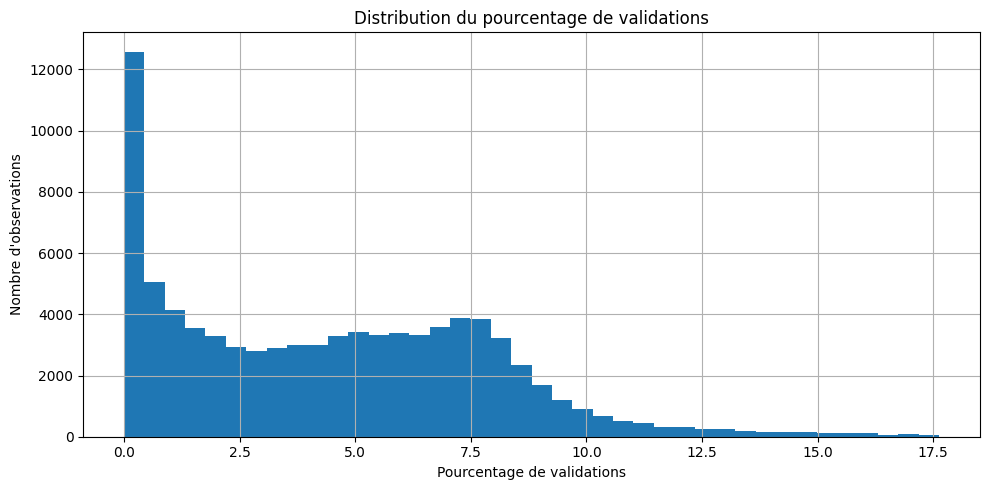

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Pourcentage_validations"],
    bins=40
)

plt.xlabel("Pourcentage de validations")
plt.ylabel("Nombre d'observations")
plt.title("Distribution du pourcentage de validations")
plt.grid(True)
plt.tight_layout()
plt.show()

#  FIGURE : AFFLUENCE MOYENNE PAR HEURE

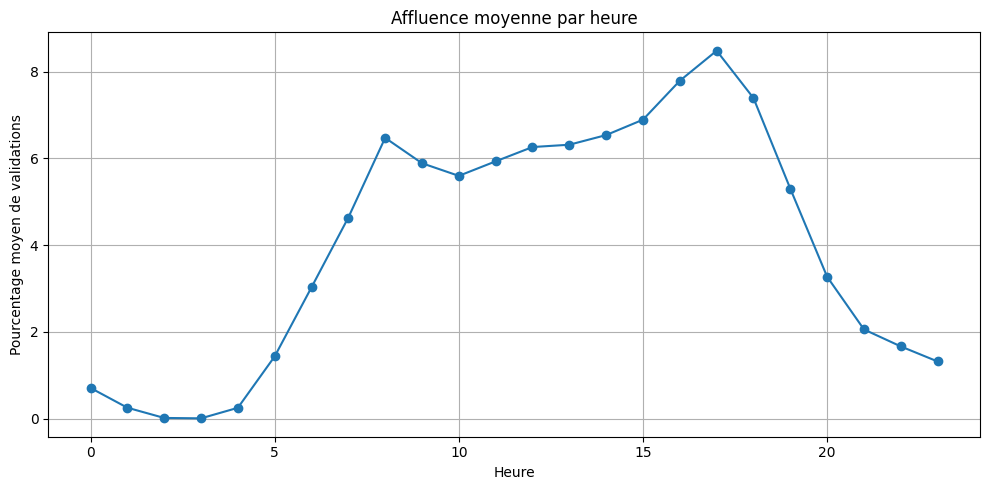

In [10]:
affluence_par_heure = (
    df.groupby("heure")["Pourcentage_validations"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    affluence_par_heure.index,
    affluence_par_heure.values,
    marker="o"
)

plt.xlabel("Heure")
plt.ylabel("Pourcentage moyen de validations")
plt.title("Affluence moyenne par heure")
plt.grid(True)
plt.tight_layout()
plt.show()

#  ENCODAGE DES VARIABLES CATÉGORIELLES

In [11]:
le_emplacement = LabelEncoder()
le_jour = LabelEncoder()
le_ligne = LabelEncoder()
le_mode = LabelEncoder()
le_exploitant = LabelEncoder()

df["emplacement_encoded"] = le_emplacement.fit_transform(
    df["nom_emplacement_trouve"]
)

df["jour_encoded"] = le_jour.fit_transform(
    df["CAT_JOUR"]
)

df["ligne_encoded"] = le_ligne.fit_transform(
    df["ligne"]
)

df["mode_encoded"] = le_mode.fit_transform(
    df["mode"]
)

df["exploitant_encoded"] = le_exploitant.fit_transform(
    df["exploitant"]
)

print("Encodage terminé.")
display(df.head())

Encodage terminé.


,nom_emplacement_trouve,CAT_JOUR,TRNC_HORR_60,heure,latitude,longitude,ligne,mode,exploitant,principale,nb_lignes,Pourcentage_validations,emplacement_encoded,jour_encoded,ligne_encoded,mode_encoded,exploitant_encoded
0,ÉPÔNE-MÉZIÈRES,JOVS,6H-7H,6,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,12.08,705,2,138,13,8
1,ÉPÔNE-MÉZIÈRES,SAHV,16H-17H,16,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,6.80,705,3,138,13,8
2,ÉPÔNE-MÉZIÈRES,SAHV,18H-19H,18,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,4.44,705,3,138,13,8
3,ÉPÔNE-MÉZIÈRES,SAHV,20H-21H,20,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,2.65,705,3,138,13,8
4,ÉPÔNE-MÉZIÈRES,SAHV,23H-0H,23,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,0.27,705,3,138,13,8


#  MATRICE DE CORRÉLATION

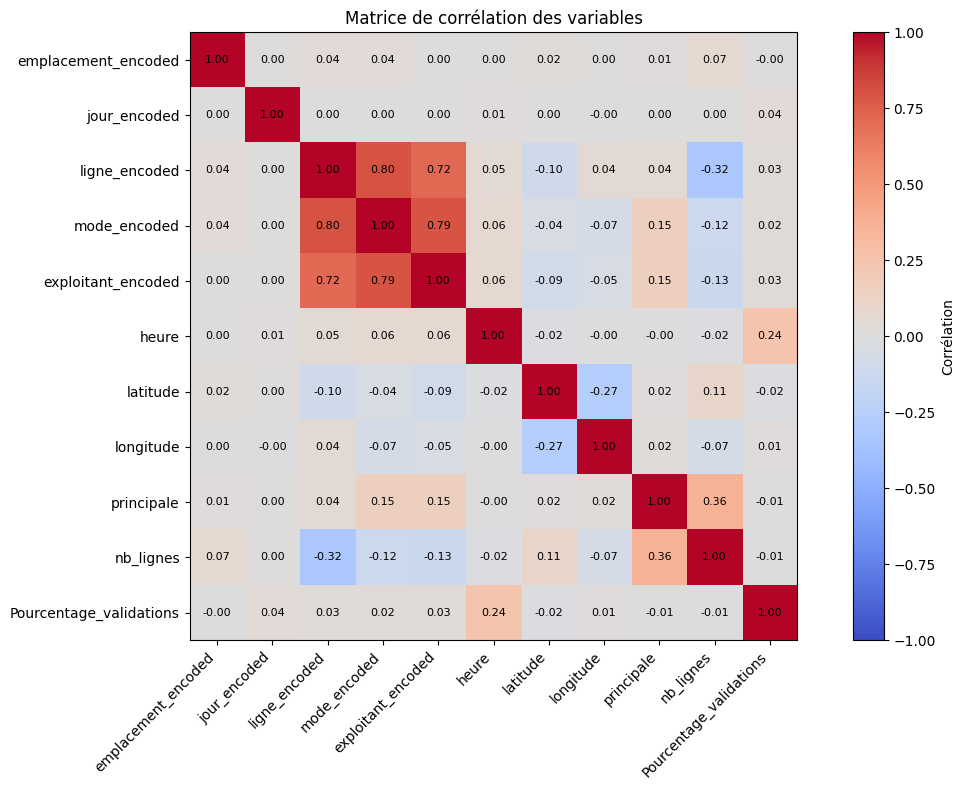

Corrélation avec la variable cible :
Pourcentage_validations    1.000000
heure                      0.243290
jour_encoded               0.038332
exploitant_encoded         0.029052
ligne_encoded              0.026798
mode_encoded               0.023993
longitude                  0.012243
emplacement_encoded       -0.002119
principale                -0.006049
nb_lignes                 -0.014230
latitude                  -0.020217
Name: Pourcentage_validations, dtype: float64


In [12]:
corr_df = df[
    [
        "emplacement_encoded",
        "jour_encoded",
        "ligne_encoded",
        "mode_encoded",
        "exploitant_encoded",
        "heure",
        "latitude",
        "longitude",
        "principale",
        "nb_lignes",
        "Pourcentage_validations"
    ]
]

correlation_matrix = corr_df.corr()

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Corrélation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Matrice de corrélation des variables")
plt.tight_layout()
plt.show()

print("Corrélation avec la variable cible :")
print(
    correlation_matrix["Pourcentage_validations"]
    .sort_values(ascending=False)
)

#  DÉFINITION DES VARIABLES X ET y

In [13]:
X = df[
    [
        "emplacement_encoded",
        "jour_encoded",
        "ligne_encoded",
        "mode_encoded",
        "exploitant_encoded",
        "heure",
        "latitude",
        "longitude",
        "principale",
        "nb_lignes"
    ]
]

y = df["Pourcentage_validations"]

print("Variables explicatives X :")
display(X.head())

print("Variable cible y :")
display(y.head())

Variables explicatives X :


,emplacement_encoded,jour_encoded,ligne_encoded,mode_encoded,exploitant_encoded,heure,latitude,longitude,principale,nb_lignes
0,705,2,138,13,8,6,48.963344,1.809095,0,2
1,705,3,138,13,8,16,48.963344,1.809095,0,2
2,705,3,138,13,8,18,48.963344,1.809095,0,2
3,705,3,138,13,8,20,48.963344,1.809095,0,2
4,705,3,138,13,8,23,48.963344,1.809095,0,2


Variable cible y :


0    12.08
1     6.80
2     4.44
3     2.65
4     0.27
Name: Pourcentage_validations, dtype: float64

#  SÉPARATION TRAIN / TEST

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test :", y_test.shape)

Taille X_train : (67776, 10)
Taille X_test : (16945, 10)
Taille y_train : (67776,)
Taille y_test : (16945,)


#  ENTRAÎNEMENT DU MODÈLE RANDOM FOREST

In [15]:
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

predictions_rf = model_rf.predict(X_test)

r2_rf = r2_score(y_test, predictions_rf)
mae_rf = mean_absolute_error(y_test, predictions_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, predictions_rf))

print("===== RANDOM FOREST =====")
print("R² :", r2_rf)
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)

===== RANDOM FOREST =====
R² : 0.8942043335135069
MAE : 0.6326343709427437
RMSE : 1.1183029732953735


In [16]:
model_et = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)

model_et.fit(X_train, y_train)

predictions_et = model_et.predict(X_test)

r2_et = r2_score(y_test, predictions_et)
mae_et = mean_absolute_error(y_test, predictions_et)
rmse_et = np.sqrt(mean_squared_error(y_test, predictions_et))

print("===== EXTRA TREES =====")
print("R² :", r2_et)
print("MAE :", mae_et)
print("RMSE :", rmse_et)

===== EXTRA TREES =====
R² : 0.8686399318141097
MAE : 0.7036662193532291
RMSE : 1.246112414564207


,Modèle,R2,MAE,RMSE
0,Random Forest,0.894204,0.632634,1.118303
1,Extra Trees,0.868640,0.703666,1.246112


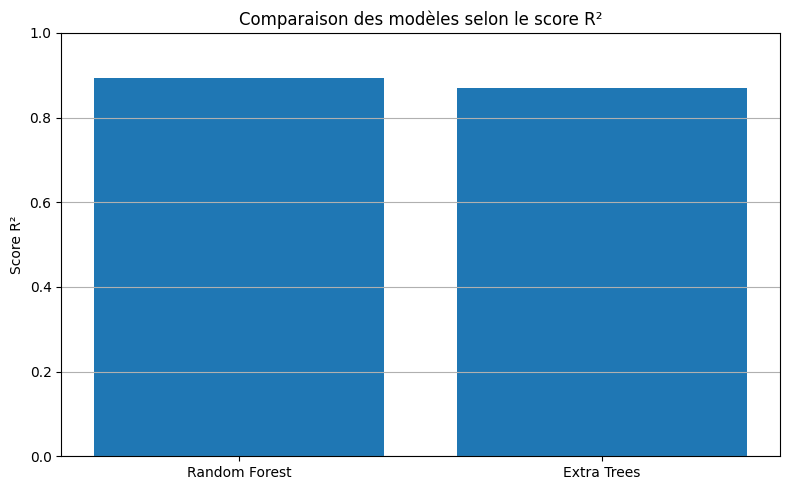

In [17]:
resultats = pd.DataFrame({
    "Modèle": [
        "Random Forest",
        "Extra Trees"
    ],
    "R2": [
        r2_rf,
        r2_et
    ],
    "MAE": [
        mae_rf,
        mae_et
    ],
    "RMSE": [
        rmse_rf,
        rmse_et
    ]
})

display(resultats)

plt.figure(figsize=(8, 5))

plt.bar(
    resultats["Modèle"],
    resultats["R2"]
)

plt.ylabel("Score R²")
plt.title("Comparaison des modèles selon le score R²")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Meilleur modèle : RandomForestRegressor
R² : 0.8942043335135069
MAE : 0.6326343709427437
RMSE : 1.1183029732953735


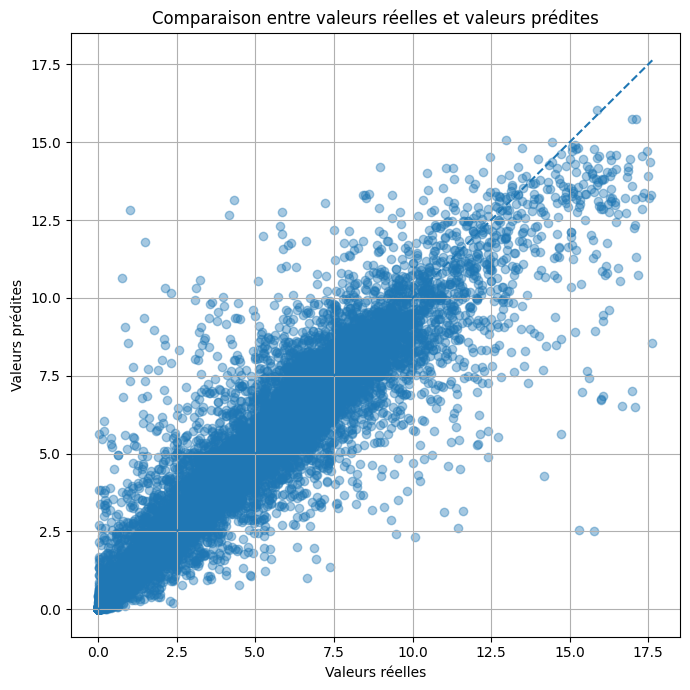

In [18]:
if r2_et > r2_rf:
    best_model = model_et
    best_model_name = "ExtraTreesRegressor"
    best_predictions = predictions_et
    best_r2 = r2_et
    best_mae = mae_et
    best_rmse = rmse_et
else:
    best_model = model_rf
    best_model_name = "RandomForestRegressor"
    best_predictions = predictions_rf
    best_r2 = r2_rf
    best_mae = mae_rf
    best_rmse = rmse_rf

print("Meilleur modèle :", best_model_name)
print("R² :", best_r2)
print("MAE :", best_mae)
print("RMSE :", best_rmse)
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Comparaison entre valeurs réelles et valeurs prédites")

min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.grid(True)
plt.tight_layout()
plt.show()

#  FIGURE : IMPORTANCE DES VARIABLES

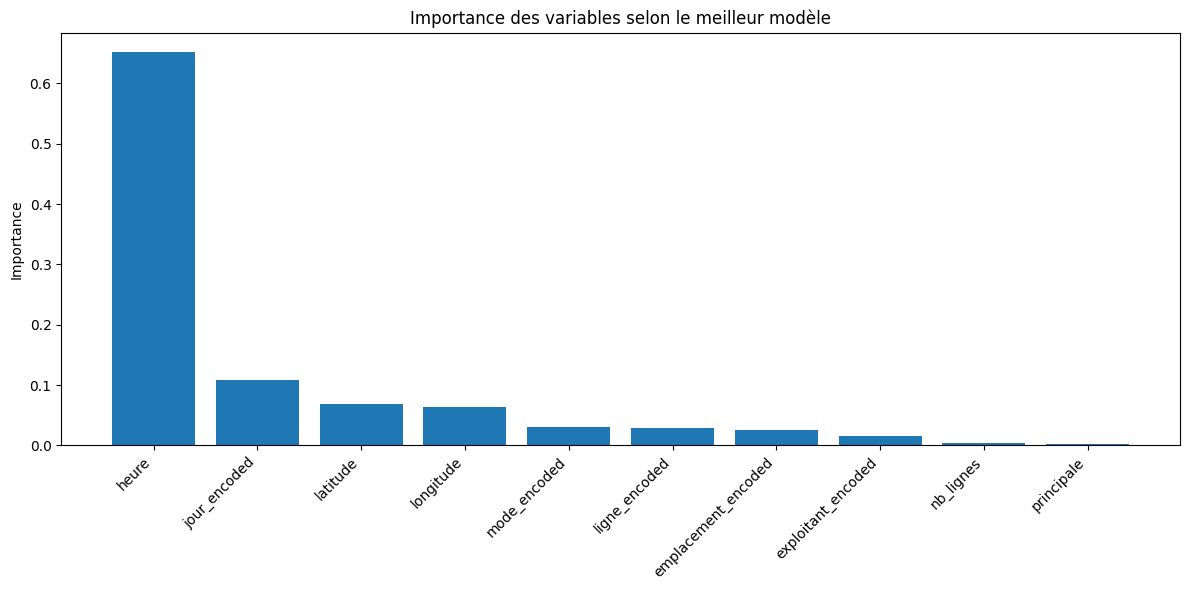

heure                  0.651324
jour_encoded           0.108272
latitude               0.068763
longitude              0.063876
mode_encoded           0.029910
ligne_encoded          0.029734
emplacement_encoded    0.025546
exploitant_encoded     0.016237
nb_lignes              0.003845
principale             0.002493
dtype: float64


In [ ]:


importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(
    importances.index,
    importances.values
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Importance des variables selon le meilleur modèle")
plt.tight_layout()
plt.show()

print(importances)

# INTERPRÉTATION DES NIVEAUX D'AFFLUENCE

In [ ]:

# On transforme la prédiction numérique en niveau :
# - faible
# - moyenne
# - forte

def niveau_affluence(valeur):
    if valeur < 4:
        return "faible"
    elif valeur < 9:
        return "moyenne"
    else:
        return "forte"


exemple_niveaux = pd.DataFrame({
    "prediction": best_predictions[:20]
})

exemple_niveaux["niveau"] = exemple_niveaux["prediction"].apply(
    niveau_affluence
)

display(exemple_niveaux)

,prediction,niveau
0,0.225527,faible
1,2.043500,moyenne
2,6.840965,forte
3,5.484027,moyenne
4,0.016756,faible
5,1.354686,faible
6,0.004958,faible
7,2.863164,moyenne
8,0.677360,faible
9,3.090300,moyenne


# TEST D'UNE PRÉDICTION CONCRÈTE

In [ ]:


exemple_station = df["nom_emplacement_trouve"].iloc[0]
exemple_jour = df["CAT_JOUR"].iloc[0]
exemple_ligne = df["ligne"].iloc[0]
exemple_mode = df["mode"].iloc[0]
exemple_exploitant = df["exploitant"].iloc[0]
exemple_latitude = df["latitude"].iloc[0]
exemple_longitude = df["longitude"].iloc[0]
exemple_principale = df["principale"].iloc[0]
exemple_nb_lignes = df["nb_lignes"].iloc[0]

exemple = pd.DataFrame([{
    "emplacement_encoded": le_emplacement.transform([exemple_station])[0],
    "jour_encoded": le_jour.transform([exemple_jour])[0],
    "ligne_encoded": le_ligne.transform([exemple_ligne])[0],
    "mode_encoded": le_mode.transform([exemple_mode])[0],
    "exploitant_encoded": le_exploitant.transform([exemple_exploitant])[0],
    "heure": 18,
    "latitude": exemple_latitude,
    "longitude": exemple_longitude,
    "principale": exemple_principale,
    "nb_lignes": exemple_nb_lignes
}])

prediction_exemple = best_model.predict(exemple)[0]

print("Station :", exemple_station)
print("Jour :", exemple_jour)
print("Ligne :", exemple_ligne)
print("Mode :", exemple_mode)
print("Exploitant :", exemple_exploitant)
print("Heure : 18h")
print("Pourcentage d'affluence prédit :", round(prediction_exemple, 2), "%")
print("Niveau d'affluence :", niveau_affluence(prediction_exemple))

Station : ÉPÔNE-MÉZIÈRES
Jour : JOVS
Ligne : TRAIN J / TRAIN N
Mode : TRAIN
Exploitant : SNCF
Heure : 18h
Pourcentage d'affluence prédit : 3.35 %
Niveau d'affluence : moyenne


# SAUVEGARDE DU MODÈLE ET DES ENCODEURS

In [ ]:


joblib.dump(best_model, "model_metro.pkl")

joblib.dump(le_emplacement, "le_emplacement.pkl")
joblib.dump(le_jour, "le_jour.pkl")
joblib.dump(le_ligne, "le_ligne.pkl")
joblib.dump(le_mode, "le_mode.pkl")
joblib.dump(le_exploitant, "le_exploitant.pkl")

print("Modèle et encodeurs sauvegardés avec succès.")

Modèle et encodeurs sauvegardés avec succès.


#  CRÉATION DU JSON POUR LA CARTE FRONTEND

In [ ]:

zones_metro = df[
    [
        "nom_emplacement_trouve",
        "latitude",
        "longitude",
        "ligne",
        "mode",
        "exploitant",
        "principale",
        "nb_lignes"
    ]
].drop_duplicates().copy()

zones_metro = zones_metro.rename(columns={
    "nom_emplacement_trouve": "nom"
})

zones_metro["type"] = "metro"
zones_metro["id"] = range(1, len(zones_metro) + 1)

zones_metro = zones_metro[
    [
        "id",
        "nom",
        "latitude",
        "longitude",
        "ligne",
        "mode",
        "exploitant",
        "principale",
        "nb_lignes",
        "type"
    ]
]

zones_metro.to_json(
    "zones_metro.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("zones_metro.json créé avec succès.")
print("Nombre de zones :", len(zones_metro))

display(zones_metro.head())

zones_metro.json créé avec succès.
Nombre de zones : 711


,id,nom,latitude,longitude,ligne,mode,exploitant,principale,nb_lignes,type
0,1,ÉPÔNE-MÉZIÈRES,48.963344,1.809095,TRAIN J / TRAIN N,TRAIN,SNCF,0,2,metro
11,2,ÉRAGNY-NEUVILLE,49.017686,2.090182,TRAIN J,TRAIN,SNCF,0,1,metro
30,3,ASNIÈRES-SUR-SEINE,48.905818,2.283021,TRAIN J / TRAIN L,TRAIN,SNCF,0,2,metro
50,4,GARCHES-MARNES-LA-COQUETTE,48.838283,2.187111,TRAIN L,TRAIN,SNCF,0,1,metro
71,5,GARGENVILLE,48.982980,1.808908,TRAIN J,TRAIN,SNCF,0,1,metro
